# Tugas Besar IF3270 — Pengujian Implementasi FFNN

**Dataset:** `data/datasetml_2026.csv`

**Anggota / Nama:** 
- 

---

## 0. Setup & Import Libraries

In [1]:
# Basic imports
import os, sys, importlib, importlib.util, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.neural_network import MLPClassifier

RANDOM_STATE = 42
sns.set(style="whitegrid")
%matplotlib inline

# Ensure the src folder (notebook location) is importable so `model` package can be found
src_dir = os.getcwd()
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

# Compatibility shim: preload `model.initializer` module and make sure it exposes `Initializer`
try:
    init_path = os.path.join(src_dir, 'model', 'initializer.py')
    if os.path.exists(init_path):
        spec = importlib.util.spec_from_file_location('model.initializer', init_path)
        init_mod = importlib.util.module_from_spec(spec)
        sys.modules['model.initializer'] = init_mod
        spec.loader.exec_module(init_mod)
        # Some files may define `Initializers` instead of `Initializer` — alias if needed
        if not hasattr(init_mod, 'Initializer') and hasattr(init_mod, 'Initializers'):
            init_mod.Initializer = getattr(init_mod, 'Initializers')
except Exception as _e:
    print('Warning while preparing initializer shim:', _e)

# Try to import user's FFNN implementation (model folder)
FFNN = None
Layer = None
try:
    from model.model import FFNN as _FFNN, Layer as _Layer
    FFNN, Layer = _FFNN, _Layer
    print('Imported custom FFNN from model.model')
except Exception as e:
    print('Could not import custom FFNN (model.model).')
    print('Error:', e)

Imported custom FFNN from model.model


## 1. Load Dataset

Muat dataset `data/datasetml_2026.csv` dan tampilkan ringkasan awal.

In [2]:
DATA_PATH = os.path.join('data', 'datasetml_2026.csv')
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
display(df.head())
display(df.describe(include='all'))
print('Target distribution:')
print(df['placement_status'].value_counts())
print(df['placement_status'].value_counts(normalize=True).round(3))


Shape: (10000, 12)


,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
count,10000.000000,10000.000000,10000,10000,10000,10000.00000,10000.000000,10000.000000,10000,10000,10000.000000,10000
unique,NaN,NaN,3,5,3,NaN,NaN,NaN,5,6,NaN,2
top,NaN,NaN,Tier 2,Germany,300+,NaN,NaN,NaN,Data Science,Consulting,NaN,Placed
freq,NaN,NaN,3993,2057,4075,NaN,NaN,NaN,2036,1739,NaN,6153
mean,6.998290,1.248100,NaN,NaN,NaN,1.49930,69.877531,65.158600,NaN,NaN,5.021436,NaN
std,0.802606,1.149904,NaN,NaN,NaN,1.20289,14.700532,14.740446,NaN,NaN,1.505975,NaN
min,4.000000,0.000000,NaN,NaN,NaN,0.00000,30.000000,30.000000,NaN,NaN,1.000000,NaN
25%,6.461928,0.000000,NaN,NaN,NaN,1.00000,59.880399,55.112244,NaN,NaN,4.012656,NaN
50%,6.997924,1.000000,NaN,NaN,NaN,1.00000,70.097368,65.006484,NaN,NaN,5.017335,NaN
75%,7.536865,2.000000,NaN,NaN,NaN,2.00000,80.213934,75.277248,NaN,NaN,6.031400,NaN


Target distribution:
placement_status
Placed        6153
Not Placed    3847
Name: count, dtype: int64
placement_status
Placed        0.615
Not Placed    0.385
Name: proportion, dtype: float64


## 2. Preprocessing

- Konversi target menjadi biner (`Placed` = 1, `Not Placed` = 0).
- One-hot encoding untuk fitur kategorikal.
- Standard scaling untuk fitur numerik (penting untuk FFNN dan MLP).


In [3]:
# Copy data
data = df.copy()

# Binary target
data['placement_target'] = data['placement_status'].map({'Placed': 1, 'Not Placed': 0})
data.drop(columns=['placement_status'], inplace=True)

# Identify numeric and categorical columns
num_cols = data.select_dtypes(include=['number']).columns.tolist()
if 'placement_target' in num_cols:
    num_cols.remove('placement_target')
cat_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()

print('Numeric cols:', num_cols)
print('Categorical cols:', cat_cols)

# One-hot encode categorical features
X = pd.get_dummies(data.drop(columns=['placement_target']), columns=cat_cols, drop_first=True)
y = data['placement_target']

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Scale numeric features
scaler = StandardScaler()
if num_cols:
    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_val[num_cols] = scaler.transform(X_val[num_cols])

# Convert to numpy arrays for the custom FFNN (if used)
X_train_np = X_train.to_numpy().astype(float)
X_val_np   = X_val.to_numpy().astype(float)
y_train_np = y_train.to_numpy().reshape(-1, 1).astype(float)
y_val_np   = y_val.to_numpy().reshape(-1, 1).astype(float)

print('X_train shape (pandas):', X_train.shape)
print('X_train shape (numpy):', X_train_np.shape)
print('y_train shape:', y_train_np.shape)


Numeric cols: ['cgpa', 'backlogs', 'internship_count', 'aptitude_score', 'communication_score', 'internship_quality_score']
Categorical cols: ['college_tier', 'country', 'university_ranking_band', 'specialization', 'industry']
X_train shape (pandas): (8000, 23)
X_train shape (numpy): (8000, 23)
y_train shape: (8000, 1)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_22012\2066880727.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()


## 3. Helpers: Build & Train Models

In [4]:
def build_ffnn(input_dim, hidden_sizes, activation='relu', output_activation='sigmoid', loss='bce', regularization=None, lam=0.0):
    """Buat dan inisialisasi FFNN sesuai API di folder `model/`."""
    model = FFNN(loss_name=loss, regularization_type=regularization, lam=lam)
    prev = input_dim
    for h in hidden_sizes:
        model.add_layer(Layer(prev, h, activation))
        prev = h

    model.add_layer(Layer(prev, 1, output_activation))
    try:
        model.initialize_weights(method='uniform', input_dim=input_dim, lower_bound=-0.1, upper_bound=0.1, seed=RANDOM_STATE)
    except Exception as e:
        print('Warning: initialize_weights failed:', e)
    return model

def train_ffnn(model, X_tr, y_tr, X_v, y_v, epochs=30, batch_size=32, learning_rate=0.01, verbose=1):
    """Fit model."""
    model.fit(X_tr, y_tr, X_v, y_v, epochs=epochs, batch_size=batch_size, learning_rate=learning_rate, verbose=verbose)
    return model.history

def train_sklearn_mlp(X_tr, y_tr, X_v, y_v, hidden_sizes=(64,64,64), activation='relu', lr=0.001, alpha=0.0001, max_iter=200):
    act_map = {'sigmoid': 'logistic', 'linear': 'identity', 'relu': 'relu', 'tanh': 'tanh'}
    act = act_map.get(activation, activation)
    mlp = MLPClassifier(hidden_layer_sizes=tuple(hidden_sizes), activation=act, solver='adam', alpha=alpha, learning_rate_init=lr, max_iter=max_iter, random_state=RANDOM_STATE)
    mlp.fit(X_tr, y_tr.ravel())
    y_pred = mlp.predict(X_v)
    report = classification_report(y_v, y_pred, output_dict=True)
    return mlp, report


### 3.1 Eksperimen: Pengaruh Depth & Width

- Pilih variasi width (3 variasi) dengan depth tetap, dan 3 variasi depth dengan width tetap.
- Visualisasikan training/validation loss per epoch dan catat metrik akhir.


Running trial: width_variant_[32, 32, 32] [32, 32, 32]


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Running trial: width_variant_[64, 64, 64] [64, 64, 64]


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Running trial: width_variant_[128, 128, 128] [128, 128, 128]
Running trial: depth_variant_[64, 64, 64] [64, 64, 64]


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Running trial: depth_variant_[64, 64, 64, 64] [64, 64, 64, 64]
Running trial: depth_variant_[64, 64, 64, 64, 64] [64, 64, 64, 64, 64]


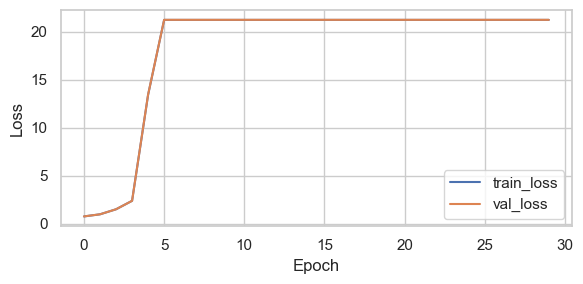

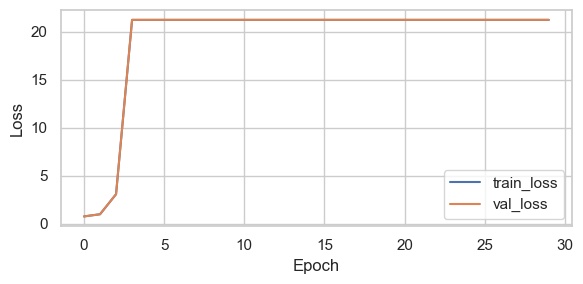

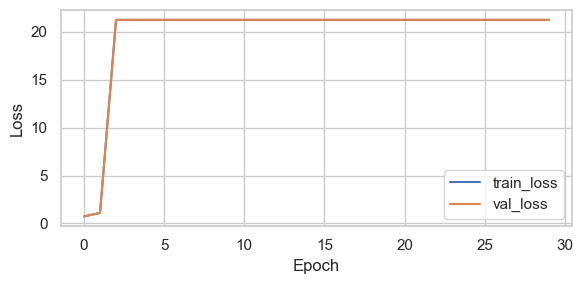

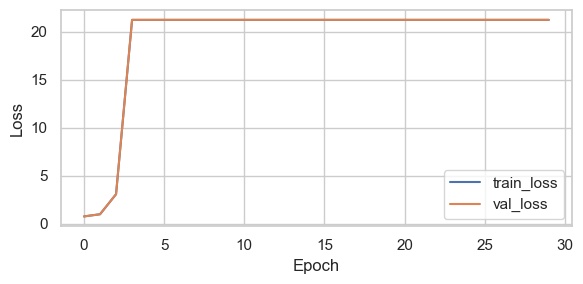

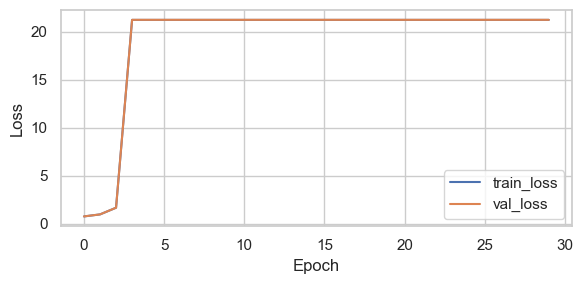

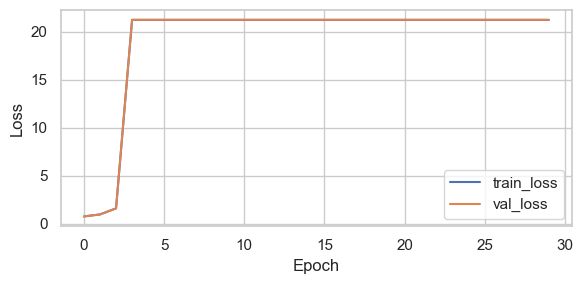

Completed depth & width experiments — results stored in `results_depth_width`.


In [5]:
results_depth_width = []

# Base architecture (depth fixed) - vary width
base_depth = 3
width_variants = [[32]*base_depth, [64]*base_depth, [128]*base_depth]

# Depth variants (width fixed)
width_fixed = 64
depth_variants = [[width_fixed]*d for d in (3,4,5)]

# Settings (kecepatan training disesuaikan agar runnable)
EPOCHS = 30
BATCH = 32
LR = 0.01

# Helper to run a single trial (tries custom FFNN first, else trains sklearn MLP for comparison)
def run_trial(hidden_sizes, desc=''):
    print('Running trial:', desc, hidden_sizes)
    record = {'hidden_sizes': hidden_sizes, 'desc': desc}
    # Custom FFNN (if available)
    if FFNN is not None:
        try:
            mdl = build_ffnn(X_train_np.shape[1], hidden_sizes, activation='relu', output_activation='sigmoid', loss='bce')
            hist = train_ffnn(mdl, X_train_np, y_train_np, X_val_np, y_val_np, epochs=EPOCHS, batch_size=BATCH, learning_rate=LR, verbose=0)
            record['ffnn_history'] = hist
            record['ffnn_model'] = mdl
            record['ffnn_val_loss'] = hist['val_loss'][-1]
        except Exception as e:
            print('FFNN run failed:', e)
    # sklearn MLP (as baseline/comparison)
    try:
        mlp, report = train_sklearn_mlp(X_train_np, y_train_np, X_val_np, y_val_np, hidden_sizes=hidden_sizes, activation='relu', lr=0.001, alpha=0.0001, max_iter=200)
        record['mlp_report'] = report
        record['mlp_macro_f1'] = report['macro avg']['f1-score']
    except Exception as e:
        print('sklearn MLP run failed:', e)
    return record

# Run width variants (depth fixed)
for w in width_variants:
    rec = run_trial(w, desc=f'width_variant_{str(w)}')
    results_depth_width.append(rec)

# Run depth variants (width fixed)
for d in depth_variants:
    rec = run_trial(d, desc=f'depth_variant_{str(d)}')
    results_depth_width.append(rec)

# Plot example: if FFNN histories exist, plot them
for r in results_depth_width:
    if 'ffnn_history' in r:
        h = r['ffnn_history']
        plt.figure(figsize=(6,3))
        plt.plot(h['train_loss'], label='train_loss')
        plt.plot(h['val_loss'], label='val_loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.tight_layout()
        plt.show()

print('Completed depth & width experiments — results stored in `results_depth_width`.')


### 3.2 Eksperimen: Aktivasi Hidden Layer

- Tentukan arsitektur dasar minimal 3 layer dan pilih 1 layer untuk divariasikan fungsi aktivasi (kecuali `softmax`).
- Catat hasil akhir prediksi dan kurva loss.


In [ ]:
activation_list = ['linear', 'relu', 'sigmoid', 'tanh']
base_arch = [64, 64, 64]  # base architecture (3 hidden layers)
test_layer_idx = 1  # indeks layer yang akan divariasikan (0-based)
results_activation = []

for act in activation_list:
    hs = base_arch.copy()
    # build activations list: all 'relu' except test layer
    activations = ['relu'] * len(hs)
    activations[test_layer_idx] = act
    desc = f'activation_test_{act}'
    print('Running activation test:', act)
    rec = {'desc': desc, 'activation': act}

    try:
        if FFNN is not None:
            # If model API only accepts single activation string per layer, we emulate by building layers with per-layer activation
            ffnn = FFNN(loss_name='bce')
            prev = X_train_np.shape[1]
            for i, h in enumerate(hs):
                ffnn.add_layer(Layer(prev, h, activations[i]))
                prev = h
            ffnn.add_layer(Layer(prev, 1, 'sigmoid'))
            try:
                ffnn.initialize_weights(method='uniform', input_dim=X_train_np.shape[1], lower_bound=-0.1, upper_bound=0.1, seed=RANDOM_STATE)
            except Exception as e:
                print('Init weights failed:', e)
            hist = train_ffnn(ffnn, X_train_np, y_train_np, X_val_np, y_val_np, epochs=EPOCHS, batch_size=BATCH, learning_rate=LR, verbose=0)
            rec['ffnn_history'] = hist
            rec['ffnn_model'] = ffnn
    except Exception as e:
        print('Custom FFNN activation test failed:', e)
        
    # sklearn MLP (single activation for all hidden layers)
    try:
        mlp_act = act if act not in ['sigmoid'] else 'logistic'
        mlp, report = train_sklearn_mlp(X_train_np, y_train_np, X_val_np, y_val_np, hidden_sizes=hs, activation=act, lr=0.001, alpha=0.0001, max_iter=200)
        rec['mlp_report'] = report
    except Exception as e:
        print('sklearn activation test failed:', e)
    results_activation.append(rec)

print('Completed activation experiments — results stored in `results_activation`.')


Running activation test: linear
Running activation test: relu


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Running activation test: sigmoid
Running activation test: tanh
Completed activation experiments — results stored in `results_activation`.


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


### 3.3 Eksperimen: Pengaruh Learning Rate

- Uji 3 variasi learning rate dan bandingkan kurva loss dan hasil akhir.

In [7]:
lr_list = [0.1, 0.01, 0.001]
results_lr = []
for lr_try in lr_list:
    print('LR=', lr_try)
    rec = {'lr': lr_try}
    try:
        if FFNN is not None:
            mdl = build_ffnn(X_train_np.shape[1], [64,64,64], activation='relu')
            hist = train_ffnn(mdl, X_train_np, y_train_np, X_val_np, y_val_np, epochs=EPOCHS, batch_size=BATCH, learning_rate=lr_try, verbose=0)
            rec['ffnn_history'] = hist
    except Exception as e:
        print('FFNN LR run failed:', e)
    # sklearn MLP with different learning rate (learning_rate_init)
    try:
        mlp, report = train_sklearn_mlp(X_train_np, y_train_np, X_val_np, y_val_np, hidden_sizes=[64,64,64], activation='relu', lr=lr_try, alpha=0.0001, max_iter=200)
        rec['mlp_report'] = report
    except Exception as e:
        print('sklearn LR run failed:', e)
    results_lr.append(rec)

print('Completed learning rate experiments. Results in `results_lr`.')


LR= 0.1
LR= 0.01
LR= 0.001
Completed learning rate experiments. Results in `results_lr`.


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


### 3.4 Eksperimen: Pengaruh Regularisasi

- Bandingkan model tanpa regularisasi, dengan L1, dan dengan L2 (satu kali percobaan masing-masing).

In [8]:
regs = [None, 'l1', 'l2']
results_reg = []
for rg in regs:
    print('Regularization:', rg)
    rec = {'reg': rg}
    try:
        if FFNN is not None:
            mdl = build_ffnn(X_train_np.shape[1], [64,64,64], activation='relu', regularization=rg, lam=0.001)
            hist = train_ffnn(mdl, X_train_np, y_train_np, X_val_np, y_val_np, epochs=EPOCHS, batch_size=BATCH, learning_rate=LR, verbose=0)
            rec['ffnn_history'] = hist
    except Exception as e:
        print('FFNN regularization run failed:', e)
    # sklearn comparison: alpha parameter == L2 penalty; sklearn does not support L1 directly in MLPClassifier (sklearn MLP supports L2 only).
    try:
        alpha = 0.001 if rg == 'l2' else 0.0
        mlp, report = train_sklearn_mlp(X_train_np, y_train_np, X_val_np, y_val_np, hidden_sizes=[64,64,64], activation='relu', lr=0.001, alpha=alpha, max_iter=200)
        rec['mlp_report'] = report
    except Exception as e:
        print('sklearn regularization run failed:', e)
    results_reg.append(rec)

print('Completed regularization experiments — results in `results_reg`.')


Regularization: None
Regularization: l1
Regularization: l2
Completed regularization experiments — results in `results_reg`.


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


### 3.5 Perbandingan Akhir dengan `sklearn.MLPClassifier`

Lakukan satu kali pelatihan dengan hyperparameter yang sama untuk kedua model (jika custom FFNN tersedia).

In [9]:
# Pilih hyperparameter untuk perbandingan akhir
final_hidden = [64,64,64]
final_lr = 0.001
final_epochs = 200

final_results = {}
# sklearn final
try:
    mlp, report = train_sklearn_mlp(X_train_np, y_train_np, X_val_np, y_val_np, hidden_sizes=final_hidden, activation='relu', lr=final_lr, alpha=0.0001, max_iter=final_epochs)
    final_results['sklearn'] = report
    print('sklearn MLP macro f1:', report['macro avg']['f1-score'])
except Exception as e:
    print('sklearn final training failed:', e)

# custom FFNN final (if available)
if FFNN is not None:
    try:
        mdl = build_ffnn(X_train_np.shape[1], final_hidden, activation='relu', loss='bce')
        hist = train_ffnn(mdl, X_train_np, y_train_np, X_val_np, y_val_np, epochs=50, batch_size=32, learning_rate=final_lr, verbose=1)
        final_results['ffnn'] = {'history': hist, 'model': mdl}
    except Exception as e:
        print('Custom FFNN final training failed:', e)

print('Final comparison stored in `final_results`.')


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


sklearn MLP macro f1: 0.6655387978920047
Epoch 1/50 - loss: 0.6873 - val_loss: 0.6873
Epoch 2/50 - loss: 0.6908 - val_loss: 0.6908
Epoch 3/50 - loss: 0.6949 - val_loss: 0.6949
Epoch 4/50 - loss: 0.6996 - val_loss: 0.6996
Epoch 5/50 - loss: 0.7050 - val_loss: 0.7050
Epoch 6/50 - loss: 0.7112 - val_loss: 0.7113
Epoch 7/50 - loss: 0.7183 - val_loss: 0.7184
Epoch 8/50 - loss: 0.7265 - val_loss: 0.7265
Epoch 9/50 - loss: 0.7357 - val_loss: 0.7358
Epoch 10/50 - loss: 0.7463 - val_loss: 0.7464
Epoch 11/50 - loss: 0.7583 - val_loss: 0.7584
Epoch 12/50 - loss: 0.7720 - val_loss: 0.7722
Epoch 13/50 - loss: 0.7876 - val_loss: 0.7877
Epoch 14/50 - loss: 0.8053 - val_loss: 0.8054
Epoch 15/50 - loss: 0.8253 - val_loss: 0.8254
Epoch 16/50 - loss: 0.8479 - val_loss: 0.8481
Epoch 17/50 - loss: 0.8735 - val_loss: 0.8737
Epoch 18/50 - loss: 0.9025 - val_loss: 0.9028
Epoch 19/50 - loss: 0.9354 - val_loss: 0.9357
Epoch 20/50 - loss: 0.9730 - val_loss: 0.9733
Epoch 21/50 - loss: 1.0159 - val_loss: 1.0163
Ep

## 4. Distribusi Bobot & Gradien

Jika custom FFNN telah dilatih di atas, jalankan visualisasi distribusi bobot dan gradien untuk beberapa layer.

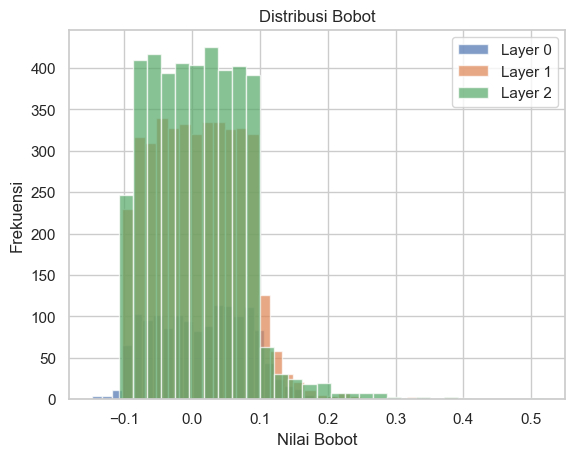

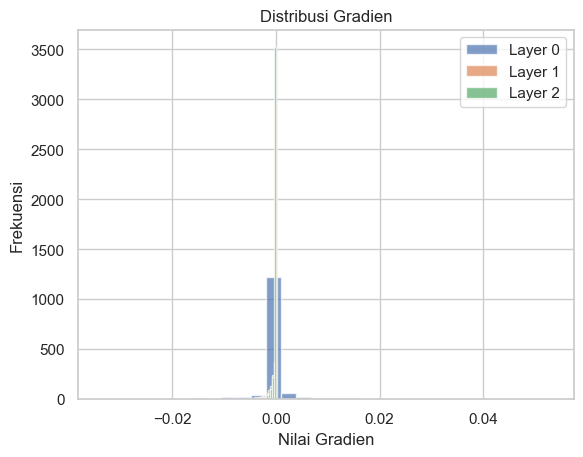

In [10]:
if 'ffnn' in final_results and final_results['ffnn'] is not None:
    mdl = final_results['ffnn']['model']
    try:
        # contoh: layer indices 0..2
        mdl.plot_weights_distribution([0, 1, 2])
        mdl.plot_gradients_distribution([0, 1, 2])
    except Exception as e:
        print('Plotting weights/gradients failed:', e)
else:
    print('Custom FFNN model not available in final_results — skipping weight/gradient plots.')


---
## Analisis

Isi bagian ini dengan hasil analisis: perbandingan metrik, interpretasi grafik training/validation loss, distribusi bobot/gradien, dan kesimpulan eksperimen sesuai `TASK.md`.

### 1) Depth & Width — Analisis


### 2) Aktivasi — Analisis


### 3) Learning Rate — Analisis


### 4) Regularisasi — Analisis


### 5) Perbandingan dengan sklearn.MLP — Analisis

